2026-07-08 02:26:13 [info     ] search_called                  provider=search_stac


2026-07-08 02:26:15 [info     ] build_tasks_start              assets=16 builder=build_grouped_tasks
Extracting...
2026-07-08 02:26:15 [info     ] execute_start                  executor=LocalExecutor task_count=8
✓ Extracted 56 artifacts
Plotting...


(<Figure size 2000x1495.93 with 2 Axes>,
 <Axes: title={'center': 'Extracted Patches Spatial Overview'}, xlabel='UTM X', ylabel='UTM Y'>)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


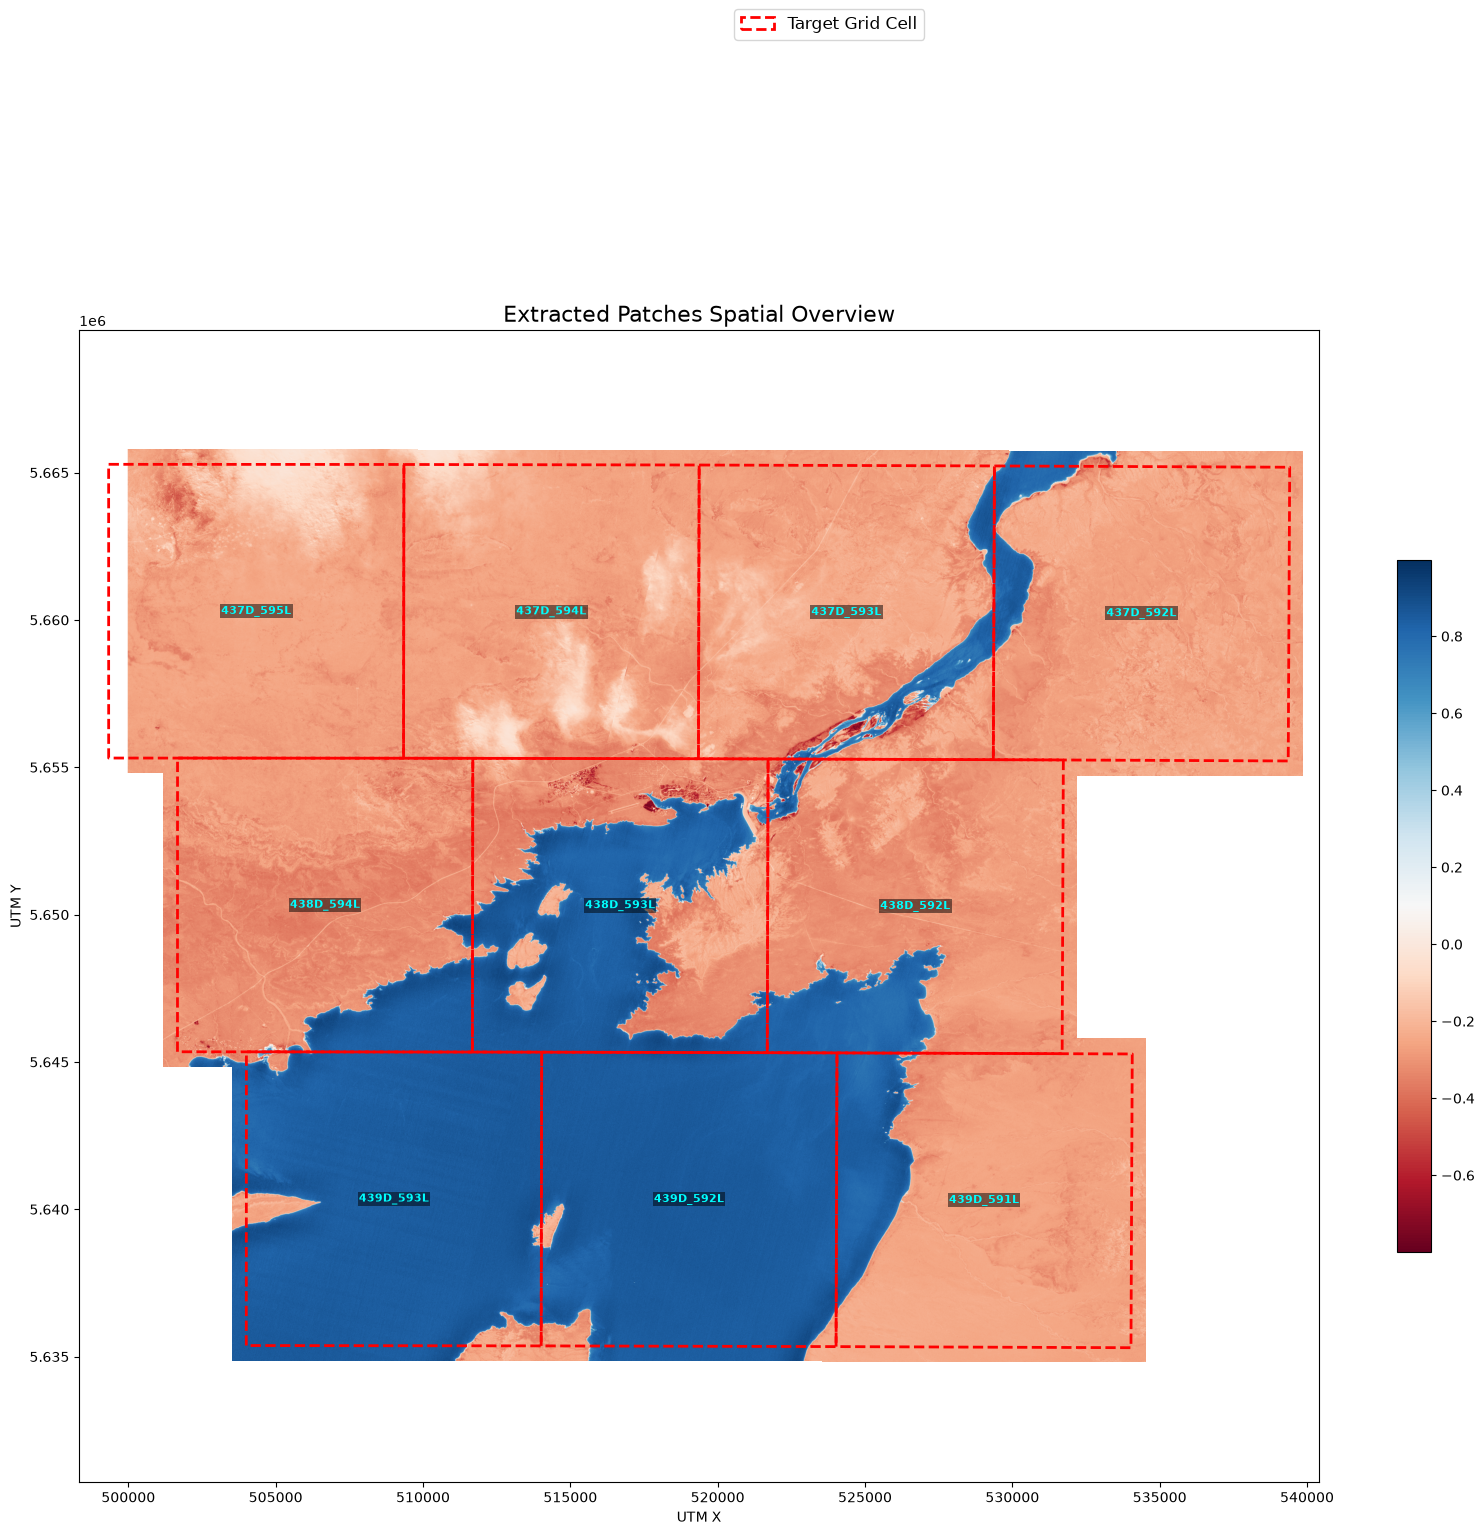

In [3]:
from aereo.cache import TaskResultCache
from aereo.executors import LocalExecutor
from aereo.pipeline import ExtractionJob
from aereo.viz import plot_artifact_patches

# Load the job from the Hydra config package.
job = ExtractionJob.load_from_config(
    config_dir="config",
    config_name="job_sentinel2-ndwi",
)
assets = job.search()  # Use the search method from the job object to get the assets.
tasks = job.build_tasks(assets)

# now we create an Executor, in this case a LocalExecutor to run
# each ExtractionTask using Threads
local_exec = LocalExecutor(workers=-1, use_threads=True, cache=TaskResultCache())
# Extract!
print("Extracting...")
artifacts = job.execute(tasks, executor=local_exec)
print(f"✓ Extracted {len(artifacts.uri.unique())} artifacts")
print("Plotting...")
plot_artifact_patches(artifacts, ds_factor=1, cmap="RdBu")